In [25]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import nltk

from nltk.corpus import stopwords
from textblob import TextBlob

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")

file_path = os.path.join(path, "tripadvisor_hotel_reviews.csv")

df = pd.read_csv(file_path)

df.head()

Using Colab cache for faster access to the 'trip-advisor-hotel-reviews' dataset.


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [28]:
df.shape

(20491, 2)

In [29]:
df.columns

Index(['Review', 'Rating'], dtype='object')

In [30]:
# Preprocess guest reviews
stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(preprocess)

df[["Review","Clean_Review"]].head()

,Review,Clean_Review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice rooms experience hotel monaco seattle goo...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [31]:
#perform Sentiment Analysis
def sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(sentiment)

df[["Rating","Sentiment"]].head()

,Rating,Sentiment
0,4,Positive
1,2,Negative
2,3,Neutral
3,5,Positive
4,5,Positive


In [32]:
#Count  Sentiments
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,15093
Negative,3214
Neutral,2184


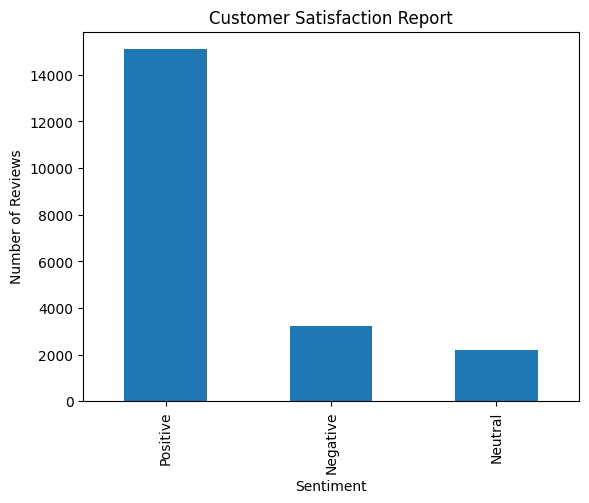

In [33]:
#plot  Sentiment Distribution

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Customer Satisfaction Report")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [34]:
#identify service related issues

keywords = ["room","staff","food","clean","service"]

print("Service Related Issues")

for word in keywords:

    count = df["Clean_Review"].str.contains(word).sum()

    print(word,":",count)

Service Related Issues
room : 17747
staff : 11915
food : 5806
clean : 8711
service : 6688


In [35]:
 # Display review for each issue

keyword = "room"

df[df["Clean_Review"].str.contains(keyword)][["Review"]].head()

,Review
0,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...
3,"unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso..."


In [36]:
#Customer Satifaction Report

print("Positive Reviews :", (df["Sentiment"]=="Positive").sum())

print("Neutral Reviews :", (df["Sentiment"]=="Neutral").sum())

print("Negative Reviews :", (df["Sentiment"]=="Negative").sum())

Positive Reviews : 15093
Neutral Reviews : 2184
Negative Reviews : 3214


In [37]:
# save final report
df.to_csv("Hotel_Review_Report.csv",index=False)

print("Report Saved Successfully")

Report Saved Successfully
